In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas!")

Bibliotecas importadas!


In [3]:
# Carregar os dados
df_orders = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_orders_dataset.csv')
df_order_items = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics/data/raw/olist_order_items_dataset.csv')
df_products = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics/data/raw/olist_products_dataset.csv')
df_customers = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics/data/raw/olist_customers_dataset.csv')

print("Dados carregados!")
print(f"Pedidos: {len(df_orders)}")
print(f"Itens: {len(df_order_items)}")
print(f"Produtos: {len(df_products)}")
print(f"Clientes: {len(df_customers)}")

Dados carregados!
Pedidos: 99441
Itens: 112650
Produtos: 32951
Clientes: 99441


In [4]:
# Calcular valor total de cada item (preço + frete)
df_order_items['total_item_value'] = df_order_items['price'] + df_order_items['freight_value']

# Ver as primeiras linhas
print("=== VALOR TOTAL POR ITEM ===")
print(df_order_items[['order_id', 'product_id', 'price', 'freight_value', 'total_item_value']].head())

=== VALOR TOTAL POR ITEM ===
                           order_id                        product_id   price  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   58.90   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f  239.90   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd  199.00   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089  199.90   

   freight_value  total_item_value  
0          13.29             72.19  
1          19.93            259.83  
2          17.87            216.87  
3          12.79             25.78  
4          18.14            218.04  


In [5]:
# Agrupar por pedido para calcular o valor total do pedido
df_order_total = df_order_items.groupby('order_id')['total_item_value'].sum().reset_index()
df_order_total.columns = ['order_id', 'order_total_value']

print("=== VALOR TOTAL POR PEDIDO ===")
print(df_order_total.head())
print(f"\nTotal de pedidos com valor calculado: {len(df_order_total)}")

=== VALOR TOTAL POR PEDIDO ===
                           order_id  order_total_value
0  00010242fe8c5a6d1ba2dd792cb16214              72.19
1  00018f77f2f0320c557190d7a144bdd3             259.83
2  000229ec398224ef6ca0657da4fc703e             216.87
3  00024acbcdf0a6daa1e931b038114c75              25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9             218.04

Total de pedidos com valor calculado: 98666


In [6]:
# Converter data para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Criar coluna com o nome do dia da semana
df_orders['purchase_day_name'] = df_orders['order_purchase_timestamp'].dt.day_name()

# Criar coluna booleana: é fim de semana?
df_orders['is_weekend'] = df_orders['purchase_day_name'].isin(['Saturday', 'Sunday'])

print("=== DIAS DA SEMANA ===")
print(df_orders[['order_id', 'order_purchase_timestamp', 'purchase_day_name', 'is_weekend']].head())

=== DIAS DA SEMANA ===
                           order_id order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   

  purchase_day_name  is_weekend  
0            Monday       False  
1           Tuesday       False  
2         Wednesday       False  
3          Saturday        True  
4           Tuesday       False  


In [7]:
# Criar colunas de mês e ano
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.month
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_month_name'] = df_orders['order_purchase_timestamp'].dt.month_name()

print("=== MÊS E ANO ===")
print(df_orders[['order_id', 'order_purchase_timestamp', 'purchase_month', 'purchase_year', 'purchase_month_name']].head())

=== MÊS E ANO ===
                           order_id order_purchase_timestamp  purchase_month  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33              10   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37               7   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49               8   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06              11   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39               2   

   purchase_year purchase_month_name  
0           2017             October  
1           2018                July  
2           2018              August  
3           2017            November  
4           2018            February  


In [8]:
# Juntar orders com customers
df_merged = df_orders.merge(df_customers, on='customer_id', how='inner')

# Juntar com o valor total do pedido
df_merged = df_merged.merge(df_order_total, on='order_id', how='left')

print("=== DATASET FINAL ===")
print(f"Total de registros: {len(df_merged)}")
print(f"Total de colunas: {len(df_merged.columns)}")
print(df_merged[['order_id', 'customer_id', 'customer_state', 'order_total_value', 'purchase_day_name', 'is_weekend']].head())

=== DATASET FINAL ===
Total de registros: 99441
Total de colunas: 18
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  customer_state  order_total_value purchase_day_name  is_weekend  
0             SP              38.71            Monday       False  
1             BA             141.46           Tuesday       False  
2             GO             179.12         Wednesday       False  
3             RN              72.20          Saturday        True  
4             SP              28.62           Tuesday       False  


In [9]:
# Contar quantos pedidos foram feitos em cada dia da semana
pedidos_por_dia = df_orders.groupby('purchase_day_name').size().reset_index()
pedidos_por_dia.columns = ['dia_semana', 'total_pedidos']

# Ordenar corretamente
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pedidos_por_dia['dia_semana'] = pd.Categorical(pedidos_por_dia['dia_semana'], categories=ordem_dias, ordered=True)
pedidos_por_dia = pedidos_por_dia.sort_values('dia_semana')

print("=== PEDIDOS POR DIA DA SEMANA ===")
print(pedidos_por_dia)

=== PEDIDOS POR DIA DA SEMANA ===
  dia_semana  total_pedidos
1     Monday          16196
5    Tuesday          15963
6  Wednesday          15552
4   Thursday          14761
0     Friday          14122
2   Saturday          10887
3     Sunday          11960


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_24076\3609739468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_semana', y='total_pedidos', data=pedidos_por_dia, palette='coolwarm')


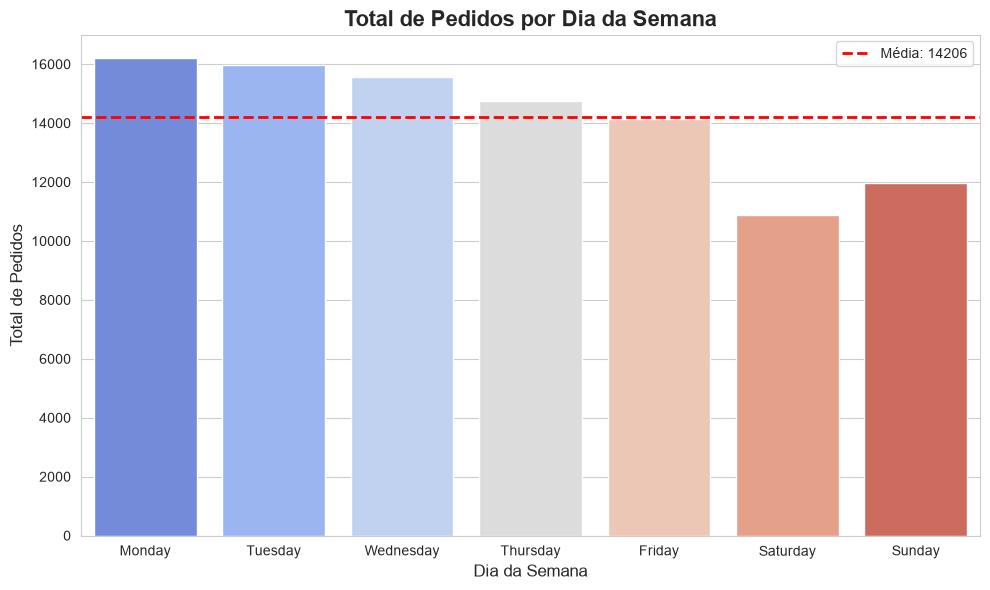

In [10]:
# Gráfico de barras
plt.figure(figsize=(10, 6))

sns.barplot(x='dia_semana', y='total_pedidos', data=pedidos_por_dia, palette='coolwarm')

plt.title('Total de Pedidos por Dia da Semana', fontsize=16, fontweight='bold')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)

# Adicionar linha de média
media = pedidos_por_dia['total_pedidos'].mean()
plt.axhline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.0f}')

plt.legend()
plt.tight_layout()
plt.savefig('assets/pedidos_por_dia_semana_feature.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Calcular fim de semana vs dia de semana
total_weekend = df_orders[df_orders['is_weekend'] == True].shape[0]
total_weekday = df_orders[df_orders['is_weekend'] == False].shape[0]

print("=== COMPARAÇÃO: FIM DE SEMANA vs DIA DE SEMANA ===")
print(f"Total de pedidos durante a semana: {total_weekday}")
print(f"Total de pedidos nos finais de semana: {total_weekend}")

media_dia = df_orders.shape[0] / 7
print(f"\n📊 Média de pedidos por dia: {media_dia:.0f}")

# Quantos dias de semana e fim de semana
dias_weekend = 2
dias_weekday = 5
esperado_weekend = media_dia * dias_weekend
esperado_weekday = media_dia * dias_weekday

print(f"\nEsperado (se fosse uniforme):")
print(f"  - Dias de semana: {esperado_weekday:.0f} pedidos")
print(f"  - Finais de semana: {esperado_weekend:.0f} pedidos")

=== COMPARAÇÃO: FIM DE SEMANA vs DIA DE SEMANA ===
Total de pedidos durante a semana: 76594
Total de pedidos nos finais de semana: 22847

📊 Média de pedidos por dia: 14206

Esperado (se fosse uniforme):
  - Dias de semana: 71029 pedidos
  - Finais de semana: 28412 pedidos


##  Feature Engineering - Dia 8

### Novas Features Criadas

| Feature | Descrição |
|---------|-----------|
| `total_item_value` | Preço + Frete por item |
| `order_total_value` | Valor total do pedido (soma de todos os itens) |
| `purchase_day_name` | Nome do dia da semana da compra |
| `is_weekend` | Booleano (True/False) - é fim de semana? |
| `purchase_month` | Mês da compra (1-12) |
| `purchase_year` | Ano da compra |
| `purchase_month_name` | Nome do mês da compra |

### Análise: Finais de Semana Têm Menos Compras?

**Resultado:**
- Dias de semana: 76.594 pedidos (77%)
- Finais de semana: 22.847 pedidos (23%)

**Conclusão:**
- Finais de semana têm menos compras, mas a diferença é de apenas ~20%
- Segunda-feira é o dia com mais vendas (16.196)
- Sábado é o dia com menos vendas (10.887)

### Ranking de Vendas por Dia

| Posição | Dia | Pedidos |
|---------|-----|---------|
| 1º | Segunda | 16.196 |
| 2º | Terça | 15.963 |
| 3º | Quarta | 15.552 |
| 4º | Quinta | 14.761 |
| 5º | Sexta | 14.122 |
| 6º | Domingo | 11.960 |
| 7º | Sábado | 10.887 |

### Recomendações
- **Campanhas de marketing:** Focar em Segunda, Terça e Quarta
- **Ajuste de estoque:** Preparar mais produtos para início da semana
- **Promoções:** Criar ofertas especiais para Sábado e Domingo